XGBOOST PERFORMANCE

Training Performance
----------------------------------------
Accuracy : 0.8594
Precision: 0.8644
Recall   : 0.7500
F1 Score : 0.8031
ROC AUC  : 0.9119

Test Performance
----------------------------------------
Accuracy : 0.8258
Precision: 0.8136
Recall   : 0.7059
F1 Score : 0.7559
ROC AUC  : 0.8573

Accuracy Gap
----------------------------------------
Training Accuracy : 0.8594
Test Accuracy     : 0.8258
Gap               : 0.0335

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.90      0.86       110
           1       0.81      0.71      0.76        68

    accuracy                           0.83       178
   macro avg       0.82      0.80      0.81       178
weighted avg       0.82      0.83      0.82       178



FEATURE IMPORTANCE

Top 15 Features

        Feature  Importance
     sex_female    0.262565
       sex_male    0.256944
         pclass    0.095444
     embarked_Q    0.064971
       is_chi

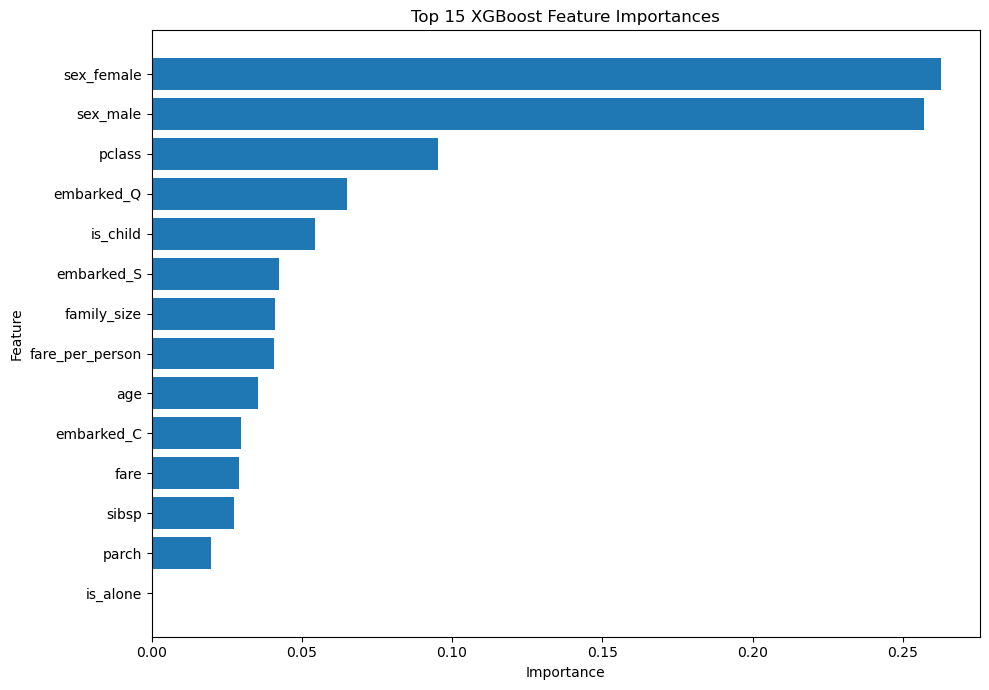

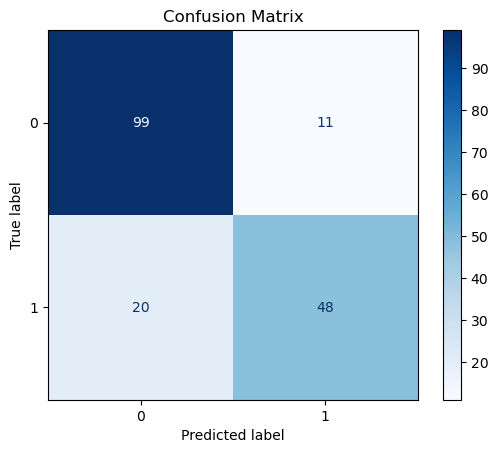

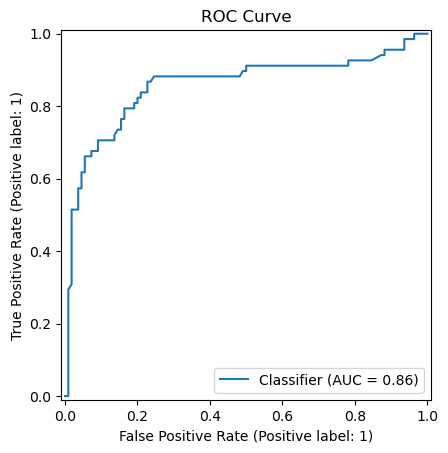

✅ Model saved successfully as 'titanic_xgboost_tuned.pkl'
✅ Model loaded successfully.

NEW PASSENGER PREDICTION
Prediction           : SURVIVED
Survival Probability : 95.12%
Death Probability    : 4.88%


In [6]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from xgboost import XGBClassifier

# =====================================================
# LOAD DATA
# =====================================================

titanic = sns.load_dataset("titanic")

# =====================================================
# DATA CLEANING
# =====================================================

titanic.drop(columns="deck", inplace=True)

titanic["age"] = titanic.groupby("pclass")["age"].transform(
    lambda x: x.fillna(x.median())
)

titanic["fare"] = titanic["fare"].fillna(
    titanic["fare"].median()
)

titanic.dropna(subset=["embarked"], inplace=True)

# =====================================================
# SIMPLE FEATURE ENGINEERING
# =====================================================

# Family size
titanic["family_size"] = (
    titanic["sibsp"] +
    titanic["parch"] +
    1
)

# Alone indicator
titanic["is_alone"] = (
    titanic["family_size"] == 1
).astype(int)

# Fare per family member
titanic["fare_per_person"] = (
    titanic["fare"] /
    titanic["family_size"]
)

# Child indicator
titanic["is_child"] = (
    titanic["age"] < 18
).astype(int)

# =====================================================
# FEATURES
# =====================================================

drop_cols = [
    "alive",
    "class",
    "who",
    "embark_town",
    "adult_male",
    "alone"
]

X = titanic.drop(
    columns=["survived"] +
    [c for c in drop_cols if c in titanic.columns]
)

y = titanic["survived"].astype(int)

categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# =====================================================
# TRAIN TEST SPLIT
# =====================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# =====================================================
# PREPROCESSING
# =====================================================

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    )
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

# =====================================================
# XGBOOST MODEL
# =====================================================

xgb = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb)
])

pipeline.fit(X_train, y_train)

# =====================================================
# TRAIN & TEST PREDICTIONS
# =====================================================

y_train_pred = pipeline.predict(X_train)
y_test_pred = pipeline.predict(X_test)

y_train_proba = pipeline.predict_proba(X_train)[:, 1]
y_test_proba = pipeline.predict_proba(X_test)[:, 1]

# =====================================================
# TRAIN METRICS
# =====================================================

train_acc = accuracy_score(y_train, y_train_pred)
train_prec = precision_score(y_train, y_train_pred)
train_rec = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_proba)

# =====================================================
# TEST METRICS
# =====================================================

test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred)
test_rec = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_proba)

# =====================================================
# RESULTS
# =====================================================

print("=" * 60)
print("XGBOOST PERFORMANCE")
print("=" * 60)

print("\nTraining Performance")
print("-" * 40)
print(f"Accuracy : {train_acc:.4f}")
print(f"Precision: {train_prec:.4f}")
print(f"Recall   : {train_rec:.4f}")
print(f"F1 Score : {train_f1:.4f}")
print(f"ROC AUC  : {train_auc:.4f}")

print("\nTest Performance")
print("-" * 40)
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall   : {test_rec:.4f}")
print(f"F1 Score : {test_f1:.4f}")
print(f"ROC AUC  : {test_auc:.4f}")

print("\nAccuracy Gap")
print("-" * 40)
print(f"Training Accuracy : {train_acc:.4f}")
print(f"Test Accuracy     : {test_acc:.4f}")
print(f"Gap               : {train_acc - test_acc:.4f}")

# =====================================================
# CLASSIFICATION REPORT
# =====================================================

print("\nClassification Report")
print("=" * 60)

print(classification_report(y_test, y_test_pred))

# =====================================================
# FEATURE IMPORTANCE
# =====================================================

print("\n")
print("=" * 60)
print("FEATURE IMPORTANCE")
print("=" * 60)

importances = pipeline.named_steps["classifier"].feature_importances_

preprocessor_fitted = pipeline.named_steps["preprocessor"]

feature_names = []

# Numerical features
feature_names.extend(numerical_features)

# One-hot encoded categorical features
encoder = (
    preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["onehot"]
)

cat_names = encoder.get_feature_names_out(categorical_features)

feature_names.extend(cat_names)

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

print("\nTop 15 Features\n")

print(importance_df.head(15).to_string(index=False))

# =====================================================
# FEATURE IMPORTANCE PLOT
# =====================================================

plt.figure(figsize=(10,7))

top = importance_df.head(15)

plt.barh(
    top["Feature"][::-1],
    top["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Feature Importances")

plt.tight_layout()
plt.show()

# =====================================================
# CONFUSION MATRIX
# =====================================================

cm = confusion_matrix(y_test, y_test_pred)

ConfusionMatrixDisplay(
    confusion_matrix=cm
).plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

# =====================================================
# ROC CURVE
# =====================================================

RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba
)

plt.title("ROC Curve")

plt.show()

# =====================================================
# SAVE MODEL
# =====================================================

import joblib

joblib.dump(pipeline, "titanic_xgboost_tuned.pkl")

print("✅ Model saved successfully as 'titanic_xgboost_tuned.pkl'")

# =====================================================
# LOAD MODEL (OPTIONAL)
# =====================================================

loaded_model = joblib.load("titanic_xgboost_tuned.pkl")

print("✅ Model loaded successfully.")

# =====================================================
# PREDICT A NEW PASSENGER
# =====================================================

new_passenger = pd.DataFrame({
    "pclass": [1],
    "sex": ["female"],
    "age": [28],
    "sibsp": [0],
    "parch": [0],
    "fare": [80],
    "embarked": ["C"],

    # Engineered features
    "family_size": [1],
    "is_alone": [1],
    "fare_per_person": [80],
    "is_child": [0]
})

prediction = loaded_model.predict(new_passenger)
probability = loaded_model.predict_proba(new_passenger)

print("\n" + "=" * 60)
print("NEW PASSENGER PREDICTION")
print("=" * 60)

if prediction[0] == 1:
    print("Prediction           : SURVIVED")
else:
    print("Prediction           : DID NOT SURVIVE")

print(f"Survival Probability : {probability[0,1]:.2%}")
print(f"Death Probability    : {probability[0,0]:.2%}")